# Create Images of Ship Sprites

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:60% !important; }</style>"))

Load in the sprite data

In [2]:
import re
from colors_map import *

sprites_files = ["uridium/src/ship_sprites.asm"]
sprites_data = {}
for sprites_file in sprites_files:
    input_file = open(sprites_file,'r')
    sprite_data = []
    for l in input_file.readlines():
        if "SPRITE" in l:
            if sprite_data:
                sprites_data[sprite_name] = sprite_data
            sprite_name = l[22:36].strip()
            sprite_data = []
            continue

        m = re.findall(r"[0-1]{24}",l)
        if not m:
            continue
        bits = m[0]
        sprite_line = []
        for i in range(0,23,2):
            bitpair = bits[i:i+2]
            sprite_line += [bitpair]
            sprite_line += [bitpair]
        sprite_data += [sprite_line]
    if sprite_data:
        sprites_data[sprite_name] = sprite_data

Function for actually drawing the sprite

In [3]:
from PIL import Image, ImageColor
SPRITE_COLS = 24
SPRITE_ROWS = 21
CELL_WIDTH = 40
CELL_HEIGHT = 40

def paintSprite(sprite, colors):
    multicol0, multicol1,color = colors
    colormap = {
        "01": multicol0,
        "10": color,
        "11": multicol1,
    }
    
    if sprite not in sprites_data:
        print(sprite)
        return
    
    image_width = SPRITE_COLS
    image_height = SPRITE_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    pixels = img.load()

    bit_array = sprites_data[sprite]
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            if bit == "00":
                continue
            pixel_color = ImageColor.getrgb(c64_to_rgb[colormap[bit]])
            pixels[x,y] = pixel_color
    return img


In [4]:
colors = (
    # cell color, text color
     "c64_yellow",
     "c64_white",
     "c64_black", 
)

sprite_images = []
for sprite_name in sprites_data:
    img = paintSprite(sprite_name, colors)
    if sprite_name == "MANTA_LEFT_9":
        img = paintSprite(sprite_name, ("c64_blue", "c64_white", "c64_black",))
    sprite_images += [img]
sprite_images[1]

### A graphic for the cover with a single sprite

In [5]:
SCALE_FACTOR = 200
img = sprite_images[1]
img = img.rotate(90)
img = img.resize((img.width * SCALE_FACTOR, img.height * SCALE_FACTOR), Image.NEAREST)
img.save("cover_sprite.png")

### A graphic for the cover with all manta sprites in a gallery

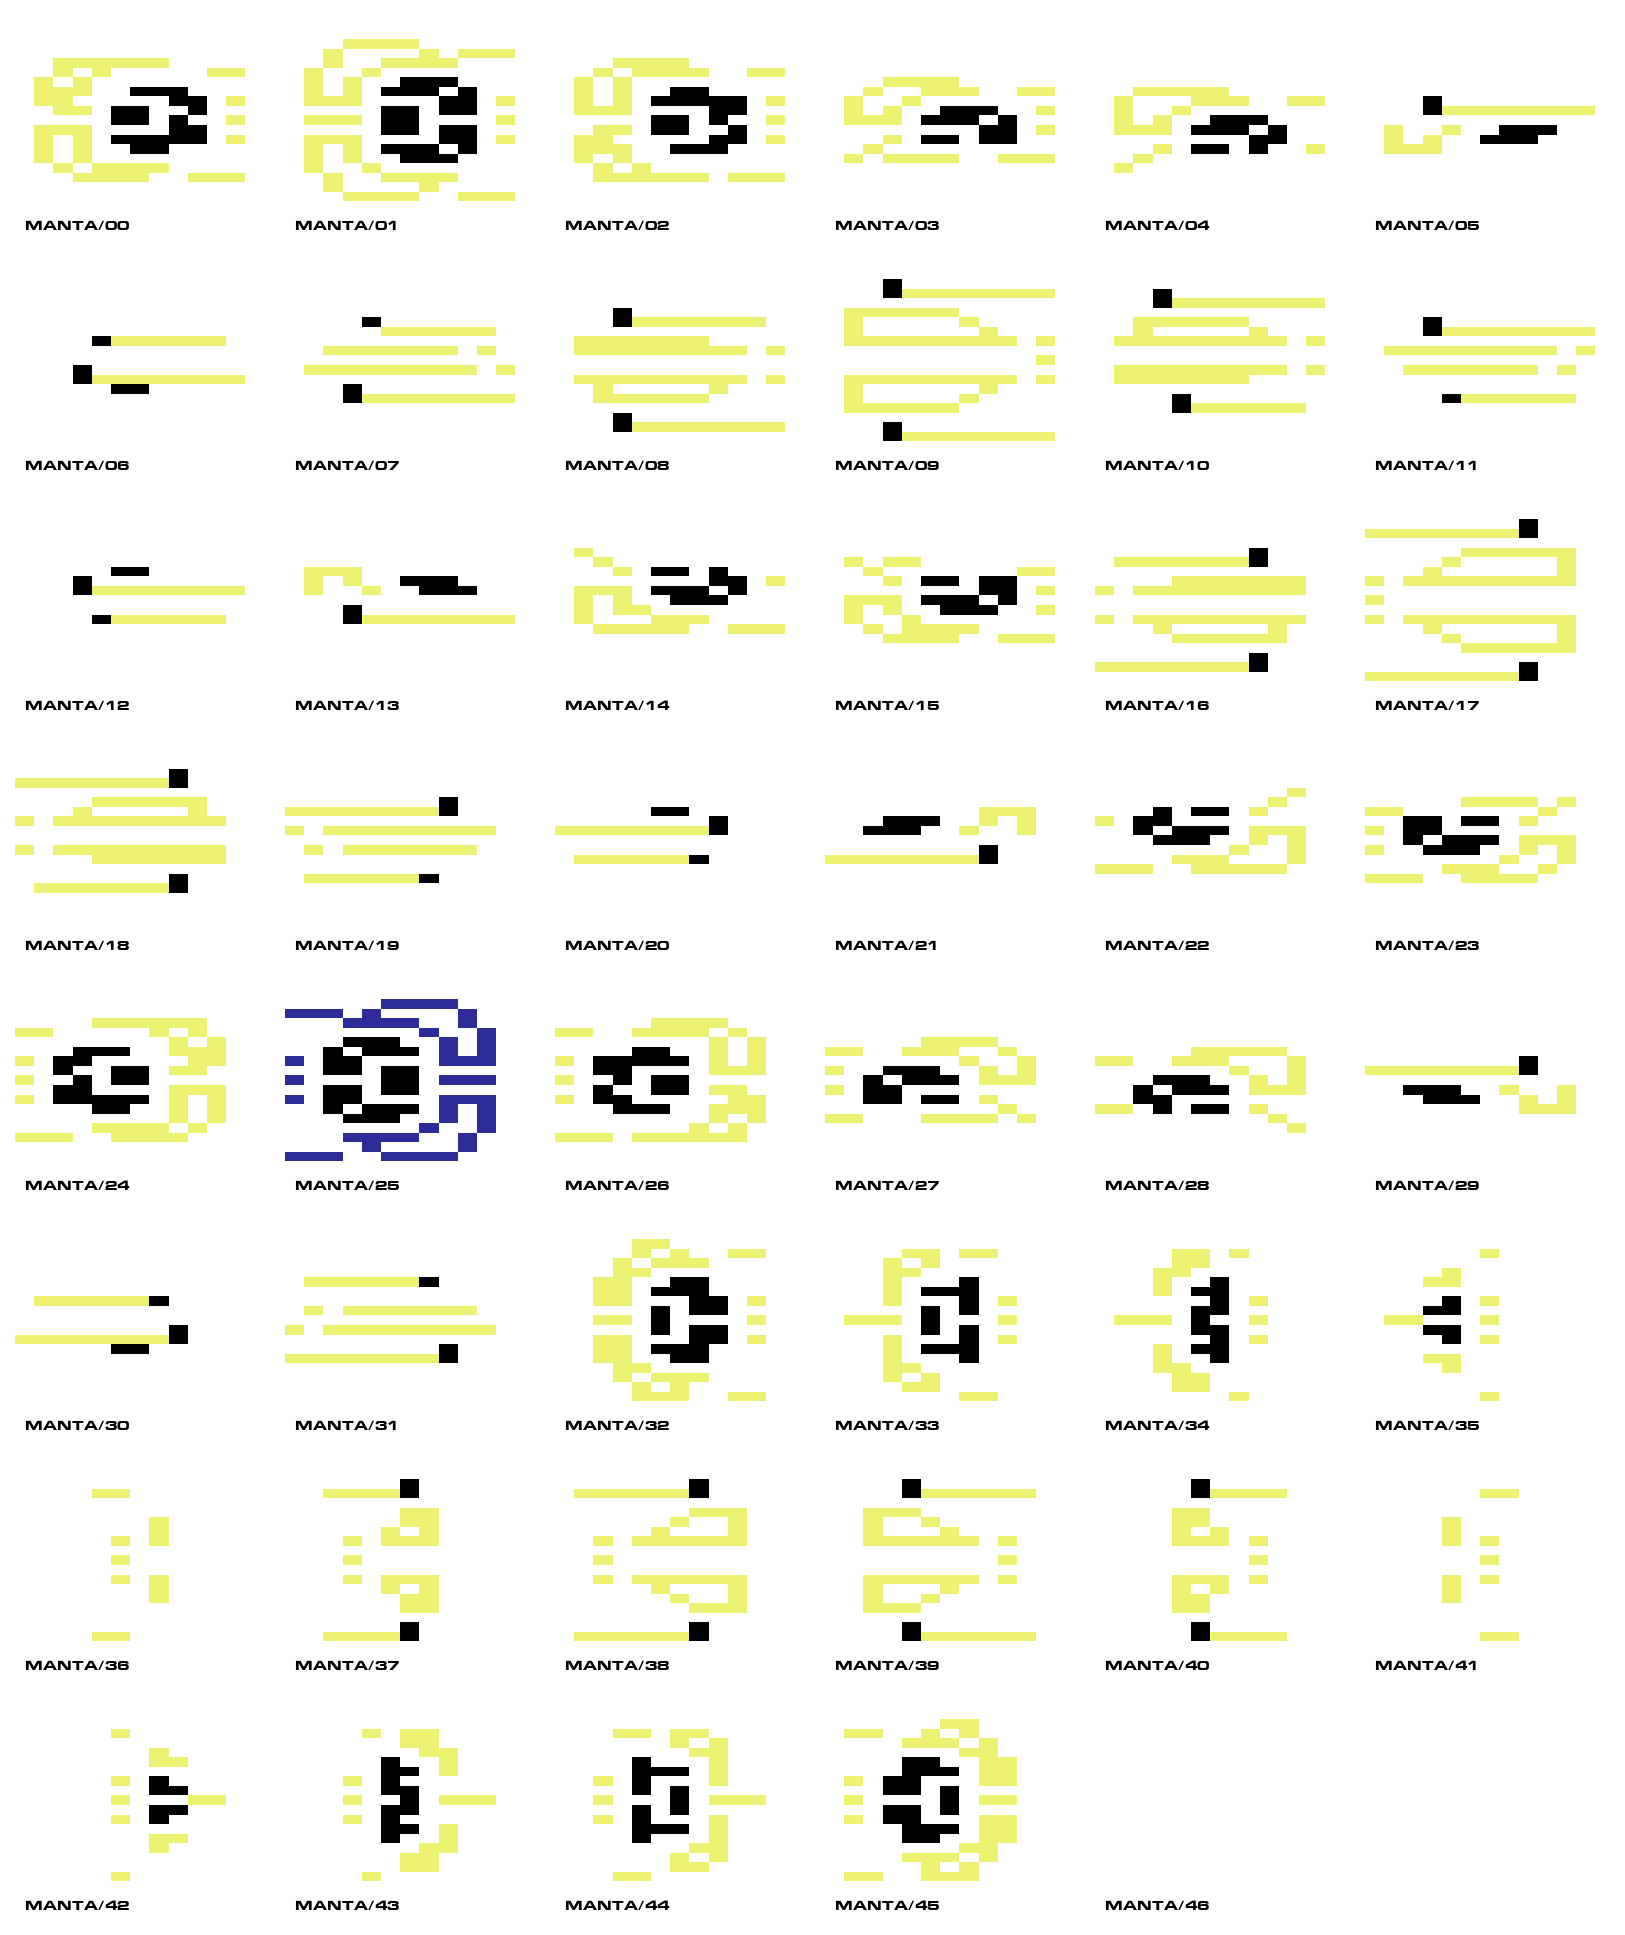

In [6]:
from PIL import Image, ImageDraw, ImageColor, ImageFont

PADDING = 15
SCALE = 10
SPRITE_WIDTH_SCALED = SPRITE_COLS * SCALE
SPRITE_HEIGHT_SCALED = SPRITE_ROWS * SCALE
CELL_WIDTH = SPRITE_WIDTH_SCALED + (PADDING * 2)
CELL_HEIGHT = SPRITE_HEIGHT_SCALED  + (PADDING * 2)

master_width =  ((CELL_WIDTH) * 6) + 5
master_height = ((CELL_HEIGHT) * 8) + 15
master_img = Image.new( 'RGBA', (master_width, master_height))
draw = ImageDraw.Draw(master_img)

x = 0
y = 5
label_fnt_size = 13
label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
for img_num, img in enumerate(sprite_images):
    img = img.resize((SPRITE_WIDTH_SCALED, SPRITE_HEIGHT_SCALED), Image.NEAREST)

    label_text = f"MANTA/{('0'+str(img_num))[-2:]}"
    txt = Image.new('RGBA', (150, 20))
    draw_label = ImageDraw.Draw(txt)
    draw_label.text((0, 0), label_text, font=label_fnt, fill="black")
    img.paste(txt, (10, CELL_HEIGHT - 40))

    master_img.paste(img, (x+PADDING,y+PADDING))
    #draw.rectangle((x, y, x + CELL_WIDTH, y + CELL_HEIGHT), width=1, outline="black")
    
    x += CELL_WIDTH
    if (x + CELL_WIDTH) > master_width:
        x = 0
        y += CELL_HEIGHT

master_img.save("cover_gallery.png")
master_img

# Scratchpad